# Notebook 03: Feature Extraction (TF-IDF vs. Word2Vec Document Embeddings)

**Deskripsi:** Notebook ini memuat dataset terbagi dari folder `data/processed/`, melakukan pencocokan dan transformasi fitur statistik **TF-IDF (Unigram + Bigram)**, melatih model kustom **Word2Vec (Skip-Gram)** pada keseluruhan korpus tersaring untuk memperkaya kosakata, serta mengekstrak **Document Embeddings** menggunakan metode **Simple Average** dan **TF-IDF Weighted Average**. Semua model pengekstraksi fitur dan matriks numerik akan disimpan untuk digunakan pada tahap pemodelan.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

# Tambahkan path parent directory agar modul 'src' bisa diimpor
sys.path.append(os.path.abspath('../'))
from src.features import (
    train_custom_word2vec,
    transform_to_word2vec_features
)

# Buat direktori model jika belum ada
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports/figures', exist_ok=True)
print("Modul ekstraksi fitur siap!")


Modul ekstraksi fitur siap!


## 1. Memuat Dataset Terproses

In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Pastikan tidak ada nilai null pada kolom teks sebelum ekstraksi
train_df['content_tfidf'] = train_df['content_tfidf'].fillna("")
train_df['content_w2v'] = train_df['content_w2v'].fillna("")

val_df['content_tfidf'] = val_df['content_tfidf'].fillna("")
val_df['content_w2v'] = val_df['content_w2v'].fillna("")

test_df['content_tfidf'] = test_df['content_tfidf'].fillna("")
test_df['content_w2v'] = test_df['content_w2v'].fillna("")

print(f"Data dimuat! Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Data dimuat! Train: 12772, Val: 2737, Test: 2738


## 2. Ekstraksi Fitur TF-IDF (Unigram + Bigram)

Kita memfit vectorizer TF-IDF pada `train_df['content_tfidf']` dan mentransformasikan set Train, Val, dan Test.

In [3]:
print("Fitting TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['content_tfidf'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['content_tfidf'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['content_tfidf'])

print(f"TF-IDF Latih   : {X_train_tfidf.shape}")
print(f"TF-IDF Validasi: {X_val_tfidf.shape}")
print(f"TF-IDF Uji     : {X_test_tfidf.shape}")

# Simpan Vectorizer TF-IDF yang telah di-fit
joblib.dump(tfidf_vectorizer, '../models/tfidf_vectorizer.joblib')
print("Vectorizer TF-IDF disimpan ke models/tfidf_vectorizer.joblib")

Fitting TF-IDF Vectorizer...


TF-IDF Latih   : (12772, 15654)
TF-IDF Validasi: (2737, 15654)
TF-IDF Uji     : (2738, 15654)
Vectorizer TF-IDF disimpan ke models/tfidf_vectorizer.joblib


## 3. Pelatihan Model Word2Vec Kustom (Skip-Gram)

Kita melatih model Word2Vec Skip-Gram (`sg=1`) pada keseluruhan korpus tersaring (Train + Val + Test) untuk memperluas kosa kata model. Ini aman secara ilmiah karena merupakan pelatihan tidak terarah (*unsupervised*) tanpa melihat label.

In [4]:
# Gabungkan seluruh ulasan tersaring untuk memperluas kosa kata Word2Vec dan meminimalkan OOV
all_sentences = [str(text).split() for text in pd.concat([train_df['content_w2v'], val_df['content_w2v'], test_df['content_w2v']])]

w2v_model = train_custom_word2vec(
    all_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    epochs=15
)

# Simpan model Word2Vec
w2v_model.save('../models/custom_word2vec.model')
print("Model Word2Vec disimpan ke models/custom_word2vec.model")

Melatih Word2Vec model kustom dengan dimensi=100, window=5...


Word2Vec kustom berhasil dilatih! Jumlah kosakata unik: 4843
Model Word2Vec disimpan ke models/custom_word2vec.model


## 3.1 Visualisasi Kata menggunakan t-SNE (t-Distributed Stochastic Neighbor Embedding)

Kami menggambar hubungan kemiripan semantik antar kata kunci emosi di ruang vektor 2D untuk memverifikasi kualitas embedding Word2Vec.

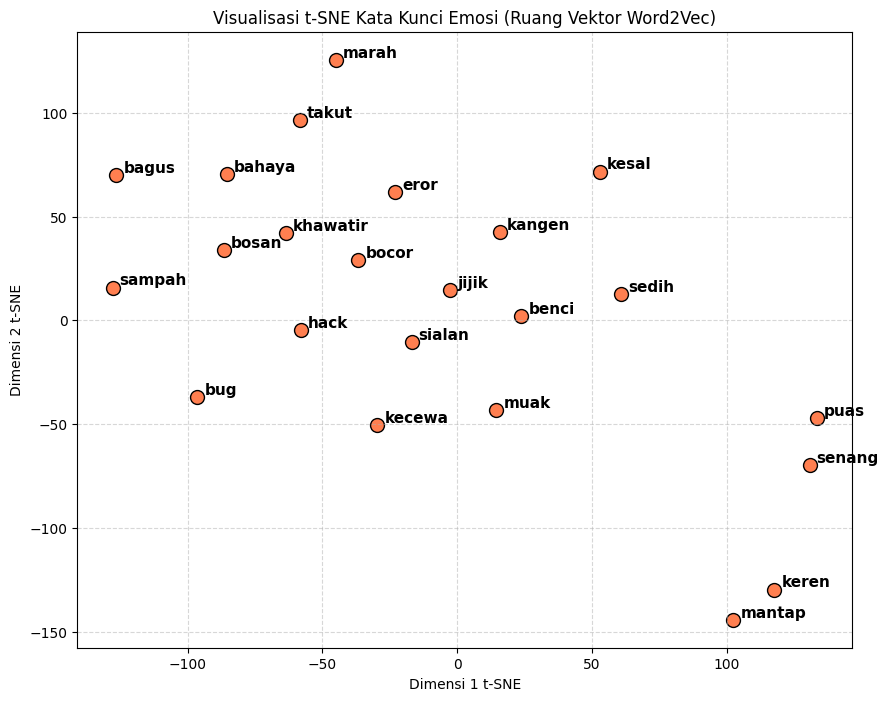

In [5]:
# Visualisasi t-SNE Kata Kunci Emosi
try:
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt
    
    # Kata kunci representatif untuk di-plot
    sample_words = [
        'bagus', 'keren', 'mantap', 'senang', 'puas',  # Joy
        'kesal', 'marah', 'benci', 'sialan', 'eror', 'bug',  # Anger
        'kecewa', 'sedih', 'nyesel', 'kangen',  # Sadness
        'takut', 'khawatir', 'bahaya', 'bocor', 'hack',  # Fear
        'muak', 'jijik', 'bosan', 'sampah', 'uninstall'  # Disgust
    ]
    
    # Pastikan kata ada dalam kosa kata model
    words_to_plot = [word for word in sample_words if word in w2v_model.wv]
    word_vectors = np.array([w2v_model.wv[word] for word in words_to_plot])
    
    if len(words_to_plot) > 0:
        tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(words_to_plot)-1))
        vectors_2d = tsne.fit_transform(word_vectors)
        
        plt.figure(figsize=(10, 8))
        plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='coral', edgecolors='black', s=100)
        
        for i, word in enumerate(words_to_plot):
            plt.annotate(
                word, 
                xy=(vectors_2d[i, 0], vectors_2d[i, 1]), 
                xytext=(5, 2), 
                textcoords='offset points', 
                fontsize=11, 
                weight='bold'
            )
            
        plt.title('Visualisasi t-SNE Kata Kunci Emosi (Ruang Vektor Word2Vec)')
        plt.xlabel('Dimensi 1 t-SNE')
        plt.ylabel('Dimensi 2 t-SNE')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.savefig('../reports/figures/word2vec_tsne.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("[WARNING] Tidak ada kata kunci leksikon yang ditemukan di kosa kata model.")
except ImportError:
    print("[WARNING] Pustaka scikit-learn manifold (TSNE) tidak terinstal. Visualisasi dilewati.")


## 4. Agregasi Vektor Dokumen (Document Embeddings)

### A. Metode Rata-Rata Sederhana (*Simple Average*)

In [6]:
print("Menghitung Simple Average Word2Vec untuk Train...")
X_train_w2v_avg = transform_to_word2vec_features(train_df, w2v_model, method='average')

print("Menghitung Simple Average Word2Vec untuk Val...")
X_val_w2v_avg = transform_to_word2vec_features(val_df, w2v_model, method='average')

print("Menghitung Simple Average Word2Vec untuk Test...")
X_test_w2v_avg = transform_to_word2vec_features(test_df, w2v_model, method='average')

print(f"Word2Vec Average Latih   : {X_train_w2v_avg.shape}")
print(f"Word2Vec Average Uji     : {X_test_w2v_avg.shape}")

Menghitung Simple Average Word2Vec untuk Train...


Menghitung Simple Average Word2Vec untuk Val...
Menghitung Simple Average Word2Vec untuk Test...
Word2Vec Average Latih   : (12772, 100)
Word2Vec Average Uji     : (2738, 100)


### B. Metode Rata-Rata Tertimbang TF-IDF (*TF-IDF Weighted Average*)

Metode ini memerlukan model pembobotan TF-IDF yang di-fit khusus pada data `content_w2v`.

In [7]:
print("Fitting TF-IDF khusus untuk pembobotan Word2Vec...")
w2v_tfidf_vectorizer = TfidfVectorizer(min_df=2, max_df=0.9)
w2v_tfidf_vectorizer.fit(train_df['content_w2v'])

print("Menghitung TF-IDF Weighted Word2Vec untuk Train...")
X_train_w2v_weighted = transform_to_word2vec_features(
    train_df, w2v_model, method='tfidf_weighted', tfidf_vectorizer=w2v_tfidf_vectorizer
)

print("Menghitung TF-IDF Weighted Word2Vec untuk Val...")
X_val_w2v_weighted = transform_to_word2vec_features(
    val_df, w2v_model, method='tfidf_weighted', tfidf_vectorizer=w2v_tfidf_vectorizer
)

print("Menghitung TF-IDF Weighted Word2Vec untuk Test...")
X_test_w2v_weighted = transform_to_word2vec_features(
    test_df, w2v_model, method='tfidf_weighted', tfidf_vectorizer=w2v_tfidf_vectorizer
)

print(f"Word2Vec Weighted Latih   : {X_train_w2v_weighted.shape}")
print(f"Word2Vec Weighted Uji     : {X_test_w2v_weighted.shape}")

# Simpan vectorizer TF-IDF pembobot
joblib.dump(w2v_tfidf_vectorizer, '../models/w2v_tfidf_vectorizer.joblib')
print("Vectorizer pembobot disimpan ke models/w2v_tfidf_vectorizer.joblib")

Fitting TF-IDF khusus untuk pembobotan Word2Vec...
Menghitung TF-IDF Weighted Word2Vec untuk Train...


Menghitung TF-IDF Weighted Word2Vec untuk Val...


Menghitung TF-IDF Weighted Word2Vec untuk Test...


Word2Vec Weighted Latih   : (12772, 100)
Word2Vec Weighted Uji     : (2738, 100)
Vectorizer pembobot disimpan ke models/w2v_tfidf_vectorizer.joblib


## 5. Serialisasi Matriks Fitur Numerik

Untuk efisiensi komputasi di tahap pemodelan, kita menyimpan seluruh matriks fitur biner yang telah diekstrak menggunakan joblib.

In [8]:
feature_dict = {
    'X_train_tfidf': X_train_tfidf,
    'X_val_tfidf': X_val_tfidf,
    'X_test_tfidf': X_test_tfidf,
    
    'X_train_w2v_avg': X_train_w2v_avg,
    'X_val_w2v_avg': X_val_w2v_avg,
    'X_test_w2v_avg': X_test_w2v_avg,
    
    'X_train_w2v_weighted': X_train_w2v_weighted,
    'X_val_w2v_weighted': X_val_w2v_weighted,
    'X_test_w2v_weighted': X_test_w2v_weighted,
    
    'y_train': train_df['emotion'].values,
    'y_val': val_df['emotion'].values,
    'y_test': test_df['emotion'].values
}

joblib.dump(feature_dict, '../data/processed/extracted_features.joblib')
print("Semua matriks fitur berhasil disimpan ke data/processed/extracted_features.joblib!")

Semua matriks fitur berhasil disimpan ke data/processed/extracted_features.joblib!
